In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
from random import shuffle
from circularplots import *

np.random.seed(42)

# use Arial
try: 
    font_path = '/home/emil/.fonts/ARIAL.TTF'  # Your font path goes here
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except:
    print('Arial font not found, using default')

# global figure size settings
figscale = 2/3
figsize = (4.5* figscale, 2 * figscale)

# plotting colors
colors = [(r/0xff, g/0xff, b/0xff) for r,g,b in [(0x67, 0x19, 0x70), (0xee, 0x96, 0x4b), 
 (0xb6,0xd0, 0x94), (0x66, 0x00, 0x00), (0xab, 0x81, 0xcd), (0x00, 0x6d, 0x6f),
 (0xe5, 0x62, 0x5e), (0xba, 0xde, 0xfc), (0x87, 0x8e, 0x99), (0x29, 0x70, 0x45),
 (0xff, 0xbf, 0xa0)]]

# working directory
wd = os.path.abspath(os.getcwd()).removesuffix('Code/panGenomeAnalysis')
fig_dir = wd + 'Figures/'

# functions
def short_lat_name(name):
    genus, species = name.split()
    return f'{genus[0]}. {species}'

def calc_pan_core(pav, n_permutations, accs):
    pangenome_sizes = []
    core_sizes = []

    pans = []
    cores = []
    for _ in range(n_permutations):
        pangenome_sizes = []
        core_sizes = []
        curr_pangenome = np.array([False] * pav.shape[1])
        curr_core = np.array([True] * pav.shape[1])
        shuffle(accs)
        for acc in accs:
            # pangenome size
            curr_pangenome |= pav.loc[acc, :]
            pangenome_sizes.append(curr_pangenome.sum())

            # core size
            curr_core &= pav.loc[acc, :]
            core_sizes.append(curr_core.sum())
        pans.append(pangenome_sizes)
        cores.append(core_sizes)
    return pans, cores

### a

In [2]:
pav = pd.read_csv(f'{wd}Data/analysis/panGenomeAnalysis/orthofinder_N0.tsv', low_memory=False, sep='\t')
pav['HOG'] = pav['HOG'].apply(lambda s: s.removeprefix('N0.'))
pav = ~pav.set_index(['HOG']).drop(['OG', 'Gene Tree Parent Clade'], axis=1).isna().T

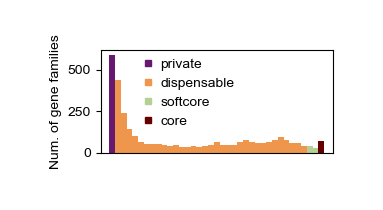

In [3]:
label_x = False
fig, ax = plt.subplots(figsize=figsize)

range_per_plot = 30

# get data
counts, bins = np.histogram(pav.mean() * pav.shape[0], bins = pav.shape[0])
poss = np.linspace(bins[0], bins[-1], len(bins) - 1)
heights = counts
breakpoint_mid = int(np.ceil(len(counts) * 0.9))
upper_limit1 = counts[counts < counts.max()].max() * 1.1
lower_limit1 = counts.max() - range_per_plot/2

# plot
box1 = ax.bar(poss[0], heights[0], width=poss[1]-poss[0], color=colors[0], label='private')
box2 = ax.bar(poss[1:breakpoint_mid], heights[1:breakpoint_mid], width=poss[1]-poss[0], color=colors[1], label='dispensable')
box3 = ax.bar(poss[breakpoint_mid:-1], heights[breakpoint_mid:-1], width=poss[1]-poss[0], color=colors[2], label='softcore')
box4 = ax.bar(poss[-1:], heights[-1:], width=poss[1]-poss[0], color=colors[3], label='core')
ax.legend(bbox_to_anchor=(0.12, 1.04), 
          #bbox_to_anchor=(0.18, 0.95),
           frameon=False, 
           handles = [mpl.lines.Line2D([], [], marker = 's', linewidth=0, markersize = 4,
                                       color=box.get_children()[0].get_facecolor())
                                       for box in [box1, box2, box3, box4]],
           labels=[box.get_label() for box in [box1, box2, box3, box4]], 
           handletextpad = 0.4, handleheight = 0.4)

# xaxis
if label_x:
    ax.set_xlabel('Number of species')
    ax.set_xticks(ax.get_xticks() + 1)
else:
    ax.tick_params(bottom=False, labelbottom=False)
ax.set_xlim(poss[0] - 2, poss[-1] + 2)
ax.set_ylabel('Num. of gene families')

# output plot
plt.savefig(fig_dir + 'pangenome_targ2_hist.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

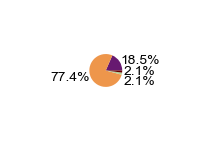

In [4]:
# pie chart
plt.figure(figsize = [val/2.5 for val in figsize])
private = counts[0]
dispensable = sum(counts[1:breakpoint_mid])
softcore = sum(counts[breakpoint_mid:-1])
core = counts[-1]
tot = private + dispensable + softcore + core
shares = [private, dispensable, softcore, core]
patches, texts = plt.pie([x for x in shares], colors = colors,
        labels=[f'{round(share/tot*100, 1)}%' for share in shares])
texts[2].set_y(-0.7)
plt.savefig(fig_dir + 'pangenome_targ2_pie.png', dpi=800, transparent=True, bbox_inches='tight')
plt.show()

In [5]:
# get number of genes of different categories
print('Total number of gene families:', sum(shares))
print('Percentage of private and dispensable genes:', round((private + dispensable) / tot, 3))
for label, number in zip(['private', 'dispensable', 'softcore', 'core'], shares):
    print(f'{label}: {number}')

Total number of gene families: 3203
Percentage of private and dispensable genes: 0.958
private: 591
dispensable: 2479
softcore: 66
core: 67


In [6]:
# what is the chance to observe the value from the study by chance in our distribution?
hypothesis = 'larger'
n = int(1e5)
n_species = [2, 7, 15]
study_values = {2: (857, 1020), 7: (289, 737), 15: (628, 828)}
ress = []
for n_s in n_species:
    res_core, res_union = [], []
    print('Number of species:', n_s)
    for _ in range(n):
        curr_orgs = np.random.choice(pav.index, size=n_s, replace=False)
        res_core.append(pav.loc[curr_orgs].all().sum())
        res_union.append(pav.loc[curr_orgs].any().sum())

    n_mean = [c/u for c,u in zip(res_core, res_union)]   
    print(f'{round(np.mean(n_mean), 4)} +- {round(np.std(n_mean), 4)}')
    print(f'{round(np.mean(res_core))} +- {round(np.std(res_core))}')
    max_s, min_s = max(n_species), min(n_species)
    print_str = 'p-values for the values from other studies: '
    if hypothesis == 'larger':
        print_str += ', '.join([str(sum([x >= study_values[n_s][i] for x in res_core]) / len(res_core)) for i in [0,1]])
    elif hypothesis == 'two-sided':
        ls = []
        res_core_mean = np.mean(res_core)
        for i in [0,1]:
            diff_test = abs(study_values[n_s][i] - res_core_mean)
            ls.append(str(
                sum([abs(x - res_core_mean) >= diff_test for x in res_core]) 
                / len(res_core)  # normalize. No correction for two-sided needed since we 
                # calculate the percentage of points further away from the mean directly
                ))
        print_str += ', '.join(ls)
    print(print_str)
    ress.append(res_core)

Number of species: 2
0.4716 +- 0.0893
714 +- 165
p-values for the values from other studies: 0.23926, 0.00748
Number of species: 7
0.1168 +- 0.0338
253 +- 73
p-values for the values from other studies: 0.29254, 0.0
Number of species: 15
0.0456 +- 0.0091
120 +- 23
p-values for the values from other studies: 0.0, 0.0


### b

In [8]:
# load data
curr_dir = f'{wd}Data/EC_predictions/PredBy2Tool/'
ec_preds = {}
for fname in os.listdir(curr_dir):
    df = pd.read_csv(curr_dir + fname, sep='\t')
    ec_preds[fname.removesuffix('.tsv')] = df

all_ecs = set.union(*(set([ec for ecs in ec_preds[org]['EC'].to_list() for ec in ecs.split('; ')]) for org in ec_preds))
ec_pav = pd.DataFrame({ec: {org: any(ec in ecs for ecs in ec_preds[org]['EC'].to_list()) for org in ec_preds} for ec in all_ecs})

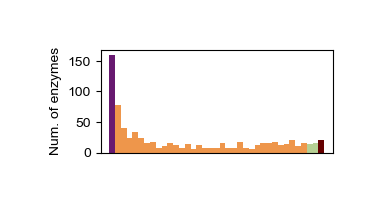

In [9]:
# plot
label_x = False
fig, ax = plt.subplots(figsize=figsize)

range_per_plot = 30

# get data
counts, bins = np.histogram(ec_pav.mean() * ec_pav.shape[0], bins = ec_pav.shape[0])
poss = np.linspace(bins[0], bins[-1], len(bins) - 1)
heights = counts
breakpoint_mid = int(np.ceil(len(counts) * 0.9))
upper_limit1 = counts[counts < counts.max()].max() * 1.1
lower_limit1 = counts.max() - range_per_plot/2

# plot each subplot
box1 = ax.bar(poss[0], heights[0], width=poss[1]-poss[0], color=colors[0], label='private')
box2 = ax.bar(poss[1:breakpoint_mid], heights[1:breakpoint_mid], width=poss[1]-poss[0], color=colors[1], label='dispensable')
box3 = ax.bar(poss[breakpoint_mid:-1], heights[breakpoint_mid:-1], width=poss[1]-poss[0], color=colors[2], label='softcore')
box4 = ax.bar(poss[-1:], heights[-1:], width=poss[1]-poss[0], color=colors[3], label='core')

# xaxis
if label_x:
    ax.set_xlabel('Number of species')
    ax.set_xticks(ax.get_xticks() + 1)
else:
    ax.tick_params(bottom=False, labelbottom=False)
ax.set_xlim(poss[0] - 2, poss[-1] + 2)
ax.set_ylabel('Num. of enzymes')
ax.set_yticks([50 * (i) for i in range(4)])

# output plot
plt.savefig(fig_dir + 'panenzome_hist.png', transparent=True, dpi=300, bbox_inches='tight')
plt.savefig(fig_dir + 'panenzome_hist.svg')
plt.show()

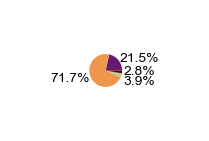

In [10]:
# pie chart
plt.figure(figsize = [val/2.5 for val in figsize])
private = counts[0]
dispensable = sum(counts[1:breakpoint_mid])
softcore = sum(counts[breakpoint_mid:-1])
core = counts[-1]
tot = private + dispensable + softcore + core
shares = [private, dispensable, softcore, core]
patches, texts = plt.pie([x for x in shares], colors = colors, labels=[f'{round(share/tot*100, 1)}%' for share in shares])
texts[2].set_y(-0.7)
plt.savefig(fig_dir + 'panenzome_pie.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [11]:
print('Number and percentage of softcore and core enzymes:', core + softcore, round((core + softcore)/tot, 3))

Number and percentage of softcore and core enzymes: 50 0.067


### c

In [12]:
# load data
rxn_pav = pd.read_csv(wd + 'Data/analysis/panGenomeAnalysis/rxnPav.csv')
rxn_pav = rxn_pav.set_index('Row')
rxn_pav.index = [s.removesuffix('.pcm.v23') for s in rxn_pav.index]

In [13]:
print('Number of reactions shared by all organism models:', rxn_pav.all().sum())
print('Number of reactions in any organism model:', rxn_pav.any().sum())
print('Percentage of core reactions:', rxn_pav.all().sum() / rxn_pav.any().sum())

Number of reactions shared by all organism models: 865
Number of reactions in any organism model: 1899
Percentage of core reactions: 0.4555028962611901


In [ ]:
# compare percentage of core reactions
n = int(1e5)
n_s = 3
comparison_value = 0.89
res_core, res_union = [], []
for i in range(n):
    if i % int(n/100) == 0:
        print(f'{round(i/n*100)} %', end = ' ' * 30 + '\r')
    curr_orgs = np.random.choice(rxn_pav.index, size=n_s, replace=False)
    res_core.append(rxn_pav.loc[curr_orgs].all().sum())
    res_union.append(rxn_pav.loc[curr_orgs].any().sum())

res_core_perc = [c/u for c,u in zip(res_core, res_union)]   
print(f'{np.mean(res_core_perc)} +- {np.std(res_core_perc)}')
# hypothesis: two-sided
ls = []
res_mean = np.mean(res_core_perc)

diff_test = abs(comparison_value - res_mean)
print('p-value that roekke value comes from this distribution (hypothesis: two-sided):', 
    sum([abs(x - res_mean) >= diff_test for x in res_core_perc]) \
    / len(res_core_perc)  # normalize. No correction for two-sided needed since we 
    # calculate the percentage of points further away from the mean directly
)

print('p-value that roekke value comes from this distribution (hypothesis: larger):', 
    sum([x >= comparison_value for x in res_core_perc]) / len(res_core_perc)
)

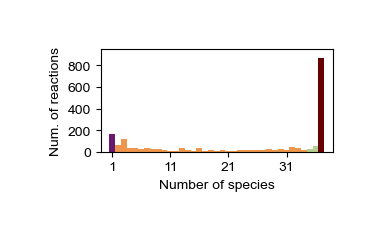

In [17]:
# histogram
fig, ax = plt.subplots(figsize=figsize)

range_per_plot = 30

# get data (in rxn_pav, the first bin is 0 because some rxns are in no model; this cannot happen with genes)
counts, bins = np.histogram(rxn_pav.mean() * rxn_pav.shape[0], bins = rxn_pav.sum().nunique())
# exclude that bin because it makes no sense in this framework)
counts = counts[1:]
bins = bins[1:]
poss = np.linspace(1, bins[-1], len(bins) - 1)
heights = counts
breakpoint_mid = int(np.ceil(len(counts) * 0.9))
upper_limit1 = counts.max() * 1.1

# plot each subplot
box1 = ax.bar(poss[0], heights[0], width=poss[1]-poss[0], color=colors[0], label='private')
box2 = ax.bar(poss[1:breakpoint_mid], heights[1:breakpoint_mid], width=poss[1]-poss[0], color=colors[1], label='dispensable')
box3 = ax.bar(poss[breakpoint_mid:-1], heights[breakpoint_mid:-1], width=poss[1]-poss[0], color=colors[2], label='softcore')
box4 = ax.bar(poss[-1:], heights[-1:], width=poss[1]-poss[0], color=colors[3], label='core')
draw_legend = False
if draw_legend:
    ax.legend(bbox_to_anchor=(0.18, 0.95), frameon=False, 
            handles = [mpl.lines.Line2D([], [], marker = 's', linewidth=0, markersize = 4,
                                        color=box.get_children()[0].get_facecolor())
                                        for box in [box1, box2, box3, box4]],
            labels=[box.get_label() for box in [box1, box2, box3, box4]], 
            handletextpad = 0.4, handleheight = 0.4)
ax.set_ylim(0, upper_limit1)
ax.set_xlabel('Number of species')
ax.set_ylabel('Num. of reactions')
ax.set_yticks([200 * (i) for i in range(5)])
xlim = ax.get_xlim()
ax.set_xticks(ax.get_xticks() + 1)
ax.set_xlim(poss[0] - 2, poss[-1] + 2)

# output plot
plt.savefig(fig_dir + 'panreactome_hist.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

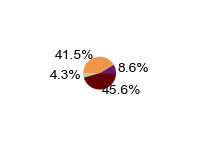

8.6
41.5
4.3
45.6


In [18]:
# pie chart
plt.figure(figsize = [val/2.5 for val in figsize])
private = counts[0]
dispensable = sum(counts[1:breakpoint_mid])
softcore = sum(counts[breakpoint_mid:-1])
core = counts[-1]
tot = private + dispensable + softcore + core
plt.pie([x for x in [private, dispensable, softcore, core]], colors = colors,
        labels=[f'{round(share/tot*100, 1)}%' for share in [private, dispensable, softcore, core]])
plt.savefig(fig_dir + 'panreactome_pie.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

tot = private + dispensable + softcore + core
print(round(private/tot*100, 1))
print(round(dispensable/tot*100, 1))
print(round(softcore/tot*100, 1))
print(round(core/tot*100, 1))

### d

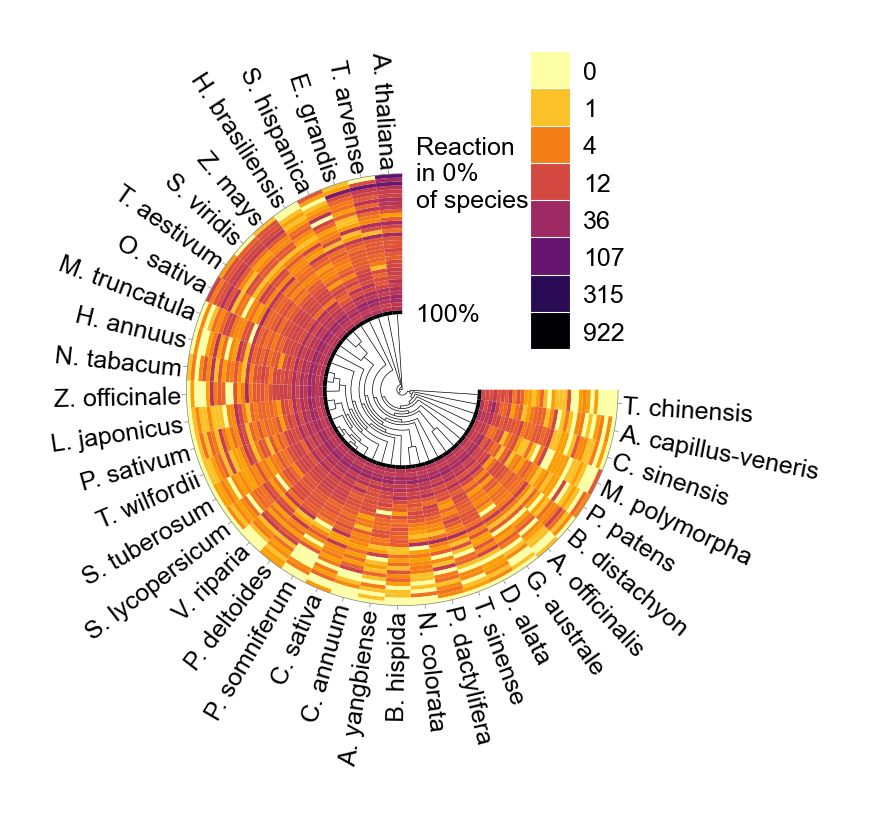

In [ ]:
def correct_spec_name(spec):
    d = {'Marchanta_polymorpha': 'Marchantia_polymorpha'}
    if spec in d:
        return d[spec]
    return spec
rxn_pav.index = [correct_spec_name(org) for org in rxn_pav.index]

data = plot_circular(rxn_pav, fig_dir + 'panreactome_circ.png', 36,
                     label_formatter=lambda x: short_lat_name(x.replace('_', ' ')),
                     axis_kws={'lw': 0}, obj = 'Reaction\n ', species_accs='species', 
                     fontsize = 18, fontsize_legend=18)

In [ ]:
# get the reactions that are unique to the pairs, causing the peaks
set1 = ['Acer_yangbiense', 'Arabidopsis_thaliana']
set2 = ['Thlaspi_arvense', 'Arabidopsis_thaliana', 'Eucalyptus_grandis']
set1_rxns = rxn_pav.loc[:, rxn_pav.loc[set1].all() & (rxn_pav.sum() == len(set1))].columns.to_list()
set2_rxns = rxn_pav.loc[:, rxn_pav.loc[set2].all() & (rxn_pav.sum() == len(set2))].columns.to_list()

with open(wd + 'Data/analysis/panGenomeAnalysis/Thla_euca_Ara_excl_rxns.txt', 'w') as file:
    for rid in set2_rxns:
        file.write(rid)
        file.write('\n')

# see analysis in cobraPy.ipynb

### supplementary table

In [21]:
def correct_spec_name(spec):
    d = {'Marchanta_polymorpha': 'Marchantia_polymorpha'}
    if spec in d:
        return d[spec]
    return spec
tmp_d = {correct_spec_name(spec).replace('_', ' '): \
               {'Number of gene families': pav.loc[spec].sum(),
                'Number of EC numbers': ec_pav.loc[spec].sum(),
                'Number of reactions': rxn_pav.loc[correct_spec_name(spec)].sum()} for spec in pav.index}
df = pd.DataFrame(tmp_d).T
df.to_csv(f'{wd}Data/supplementary/supp1.csv')